In [1]:
import numpy as np 
import pandas as pd 

np.random.seed(42)
data = {
    'Customer_ID': [f'CUST_{i:03d}' for i in range(1, 16)],
    'Branch': ['Enghelab', 'Enghelab', 'Enghelab', 'Enghelab', 'Enghelab', 
               'Tajrish', 'Tajrish', 'Tajrish', 'Tajrish', 'Tajrish',
               'Vanak', 'Vanak', 'Vanak', 'Vanak', 'Vanak'],
    'Age': [22, 24, 19, 21, 23, 35, 42, 38, 40, 65, 28, 30, 29, 31, 27],
    'Purchase_Amount_Toman': [120000, 150000, 95000, 110000, 130000, 
                              250000, 310000, 280000, 290000, 12000000, 
                              180000, 210000, 195000, 205000, 175000],
    'Books_Bought': [1, 2, 1, 1, 2, 3, 4, 3, 3, 5],
    'Satisfaction_Score_1to5': [4, 5, 3, 4, 4, 5, 4, 5, 5, 1, 4, 4, 5, 3, 4]
}

data['Books_Bought'] = [1, 2, 1, 1, 2, 3, 4, 3, 3, 5, 2, 2, 3, 1, 2]

df = pd.DataFrame(data)
df

,Customer_ID,Branch,Age,Purchase_Amount_Toman,Books_Bought,Satisfaction_Score_1to5
0,CUST_001,Enghelab,22,120000,1,4
1,CUST_002,Enghelab,24,150000,2,5
2,CUST_003,Enghelab,19,95000,1,3
3,CUST_004,Enghelab,21,110000,1,4
4,CUST_005,Enghelab,23,130000,2,4
5,CUST_006,Tajrish,35,250000,3,5
6,CUST_007,Tajrish,42,310000,4,4
7,CUST_008,Tajrish,38,280000,3,5
8,CUST_009,Tajrish,40,290000,3,5
9,CUST_010,Tajrish,65,12000000,5,1


In [2]:
mean_purchase= df['Purchase_Amount_Toman'].mean()
median_purchase= df['Purchase_Amount_Toman'].median()

print(f"Mean purchase amount: {mean_purchase:,.0f} Toman")
print(f"Median purchase amount: {median_purchase:,.0f} Toman")

difference = mean_purchase - median_purchase 
print(f"Difference Between mean purchase and median purchase:{difference:,.0f} Toman")

Mean purchase amount: 980,000 Toman
Median purchase amount: 195,000 Toman
Difference Between mean purchase and median purchase:785,000 Toman


In [7]:
q1 = df['Purchase_Amount_Toman'].quantile(0.25)
q3 = df['Purchase_Amount_Toman'].quantile(0.75)

iqr = q3 - q1 

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
print(f"Q1 (25%): {q1:,.0f} Toman")
print(f"Q3 (75%): {q3:,.0f} Toman")
print(f"IQR: {iqr:,.0f} Toman")
print(f"Upper Bound: {upper_bound:.0f} Toman") 
outliers = df[
    (df['Purchase_Amount_Toman'] < lower_bound) |
    (df['Purchase_Amount_Toman'] > upper_bound)
]
print("\n Identified Outliers(s):")
print(outliers[['Customer_ID' , 'Branch' , 'Purchase_Amount_Toman']])

Q1 (25%): 140,000 Toman
Q3 (75%): 265,000 Toman
IQR: 125,000 Toman
Upper Bound: 452500 Toman

 Identified Outliers(s):
  Customer_ID   Branch  Purchase_Amount_Toman
9    CUST_010  Tajrish               12000000


In [4]:
branch_age_stats = df.groupby('Branch')['Age'].agg(
    Mean_Age='mean',
    Std_Age=lambda x: x.std(ddof=1), 
    Customer_Count='count'
).reset_index()

print("Age Statistics by Branch:")
print(branch_age_stats)

Age Statistics by Branch:
     Branch  Mean_Age    Std_Age  Customer_Count
0  Enghelab      21.8   1.923538               5
1   Tajrish      44.0  12.020815               5
2     Vanak      29.0   1.581139               5


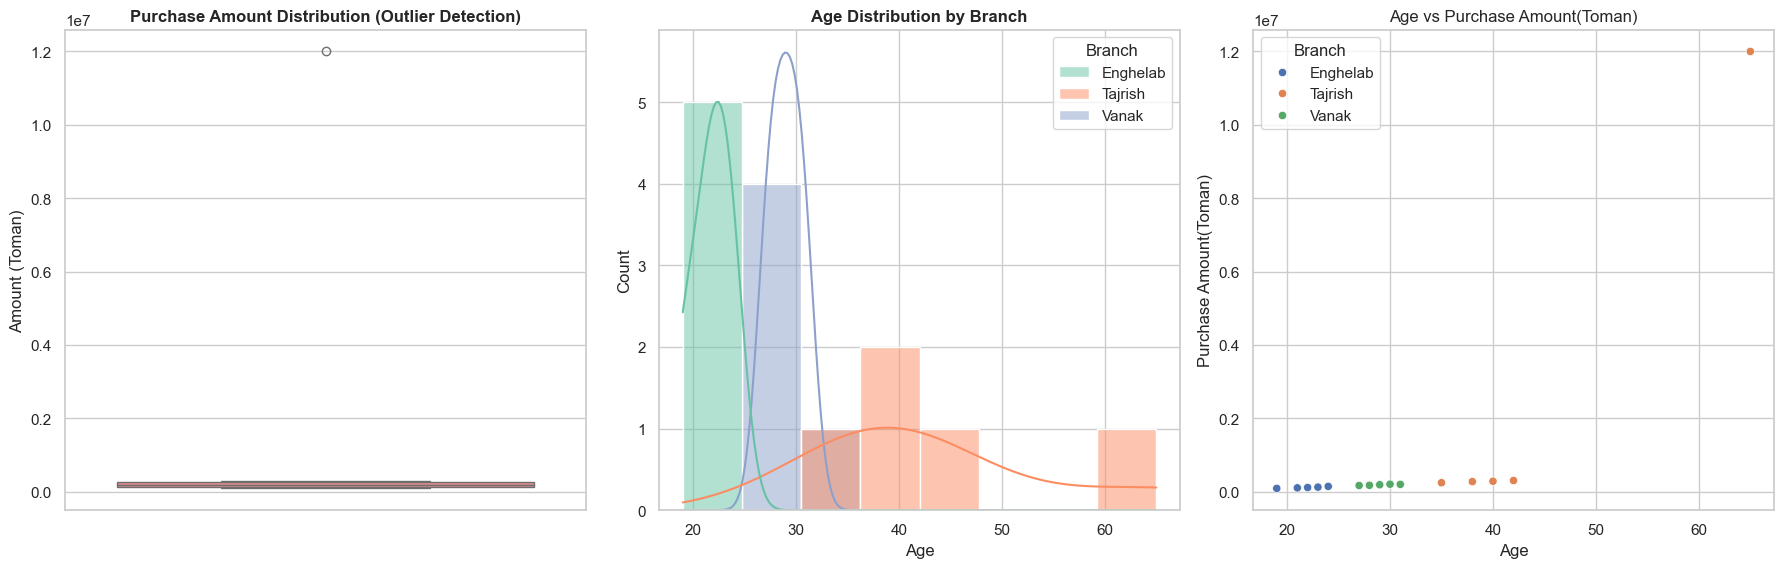

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme (style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.boxplot(data=df, y='Purchase_Amount_Toman',ax=axes[0], color='lightcoral')
axes[0].set_title('Purchase Amount Distribution (Outlier Detection)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amount (Toman)')

sns.histplot(data=df, x='Age', hue='Branch', kde=True, ax=axes[1], palette='Set2', bins=8)
axes[1].set_title('Age Distribution by Branch', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age')

sns.scatterplot(data=df, x='Age', y='Purchase_Amount_Toman', hue='Branch', ax=axes[2])
axes[2].set_title('Age vs Purchase Amount(Toman)')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Purchase Amount(Toman)')

plt.tight_layout()
plt.show()